In [37]:
import os
os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

%load_ext rpy2.ipython
%matplotlib inline

from matplotlib import rcParams
rcParams['figure.figsize'] = (14, 12)

import warnings
warnings.filterwarnings("ignore")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [38]:
%%R

require('tidyverse')
require('scales')

In [39]:
%%R

df <- read_csv("../data/pokemon_all_cleaned.csv", show_col_types = FALSE)

# Parse prices to numeric
df <- df %>%
  mutate(
    ungraded = as.numeric(gsub("[\\$, ]", "", `Ungraded Price`)),
    psa10 = as.numeric(gsub("[\\$, ]", "", `PSA 10 Price`))
  ) %>%
  filter(!is.na(ungraded) & !is.na(psa10) & ungraded > 0 & psa10 > 0)

# Top 10 species by max PSA 10 price
top10 <- df %>%
  group_by(Species) %>%
  summarise(max_psa10 = max(psa10, na.rm = TRUE)) %>%
  arrange(desc(max_psa10)) %>%
  head(10) %>%
  pull(Species)

df <- df %>%
  mutate(
    species_group = factor(
      ifelse(Species %in% top10, Species, "Other"),
      levels = c(top10, "Other")
    )
  )

cat("Top 10 most expensive species (by PSA 10):\n")
for (s in top10) cat("  ", s, "\n")
cat("\nTotal cards for plot:", nrow(df))

Top 10 most expensive species (by PSA 10):
   Charizard 
   Mewtwo 
   Rayquaza 
   Venusaur 
   Mew 
   Infernape 
   Chansey 
   Blastoise 
   Latios 
   Gengar 

Total cards for plot: 3118

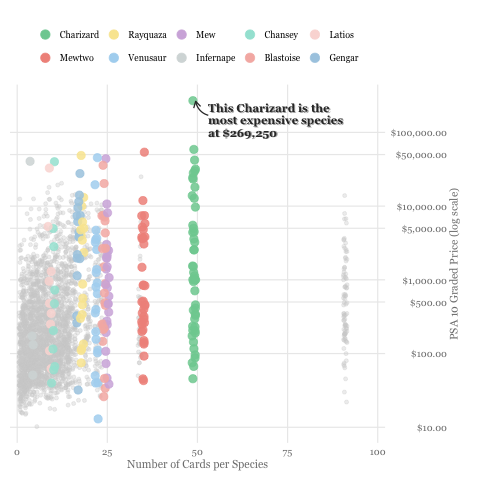

In [40]:
%%R

# Add card count per species to every row
plot_df <- df %>%
  group_by(Species) %>%
  mutate(n_cards = n()) %>%
  ungroup()

# Full data range
max_x <- max(plot_df$n_cards, na.rm = TRUE) * 1.1

# Pastel palette
species_colors <- setNames(
  c("#7dcea0", "#f1948a", "#f9e79f", "#aed6f1", "#d2b4de",
    "#d5dbdb", "#a3e4d7", "#f5b7b1", "#fadbd8", "#a9cce3"),
  top10
)

# Split data
other_df <- filter(plot_df, species_group == "Other")
top_df <- filter(plot_df, species_group != "Other")

# Highlight: most expensive card in top 10
highlight_vis <- top_df %>%
  filter(psa10 == max(psa10, na.rm = TRUE)) %>%
  head(1)

ann_x <- highlight_vis$n_cards + max_x * 0.04
ann_y <- highlight_vis$psa10 * 0.55

ann_label <- paste0(
  "This ", highlight_vis$Species, " is the\n",
  "most expensive species\n",
  "at $", format(round(highlight_vis$psa10), big.mark = ",")
)

set.seed(42)

p <- ggplot() +
  # 1. "Other" dots — smaller but more visible
  geom_jitter(data = other_df,
              aes(x = n_cards, y = psa10),
              color = "#d0d0d0", size = 1.5, alpha = 0.35, width = 0.5) +
  # 2. Top 10 — each card is a colored dot
  geom_jitter(data = top_df,
              aes(x = n_cards, y = psa10, color = species_group),
              size = 3.5, alpha = 0.85, width = 0.5) +
  # 3. Annotation shadow (slightly offset for depth)
  annotate("text",
    x = ann_x + max_x * 0.003, y = ann_y * 0.98,
    label = ann_label,
    hjust = 0, size = 4, family = "Georgia", color = "gray70",
    lineheight = 0.9, fontface = "bold"
  ) +
  # 4. Annotation text (bold, darker)
  annotate("text",
    x = ann_x, y = ann_y,
    label = ann_label,
    hjust = 0, size = 4, family = "Georgia", color = "gray20",
    lineheight = 0.9, fontface = "bold"
  ) +
  # 5. Annotation arrow (bolder)
  annotate("curve",
    x = ann_x, y = ann_y * 1.15,
    xend = highlight_vis$n_cards + max_x * 0.005,
    yend = highlight_vis$psa10 * 0.98,
    curvature = -0.3,
    arrow = arrow(length = unit(0.25, "cm")),
    color = "gray20", linewidth = 0.6
  ) +
  # Scales — log scale on y to spread out the bottom cluster
  scale_color_manual(values = species_colors) +
  scale_x_continuous(expand = c(0.02, 0)) +
  scale_y_log10(
    labels = dollar_format(),
    position = "right",
    breaks = c(10, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000)
  ) +
  coord_cartesian(xlim = c(0, max_x)) +
  labs(x = "Number of Cards per Species", y = "PSA 10 Graded Price (log scale)") +
  theme_minimal(base_size = 12, base_family = "Georgia") +
  theme(
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 9),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "gray92"),
    axis.text = element_text(color = "gray50"),
    axis.title = element_text(color = "gray50", size = 11),
    axis.title.y.right = element_text(angle = 90),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin = margin(20, 20, 10, 10)
  ) +
  guides(color = guide_legend(nrow = 2, override.aes = list(size = 4, alpha = 1)))

print(p)

In [41]:
%%R

ggsave("../data/pokemon_scatter.svg", plot = p, width = 14, height = 9, dpi = 300)
cat("Saved to pokemon_scatter.svg")

Saved to pokemon_scatter.svg